# Script to create plots in Figure 3

## File sizes

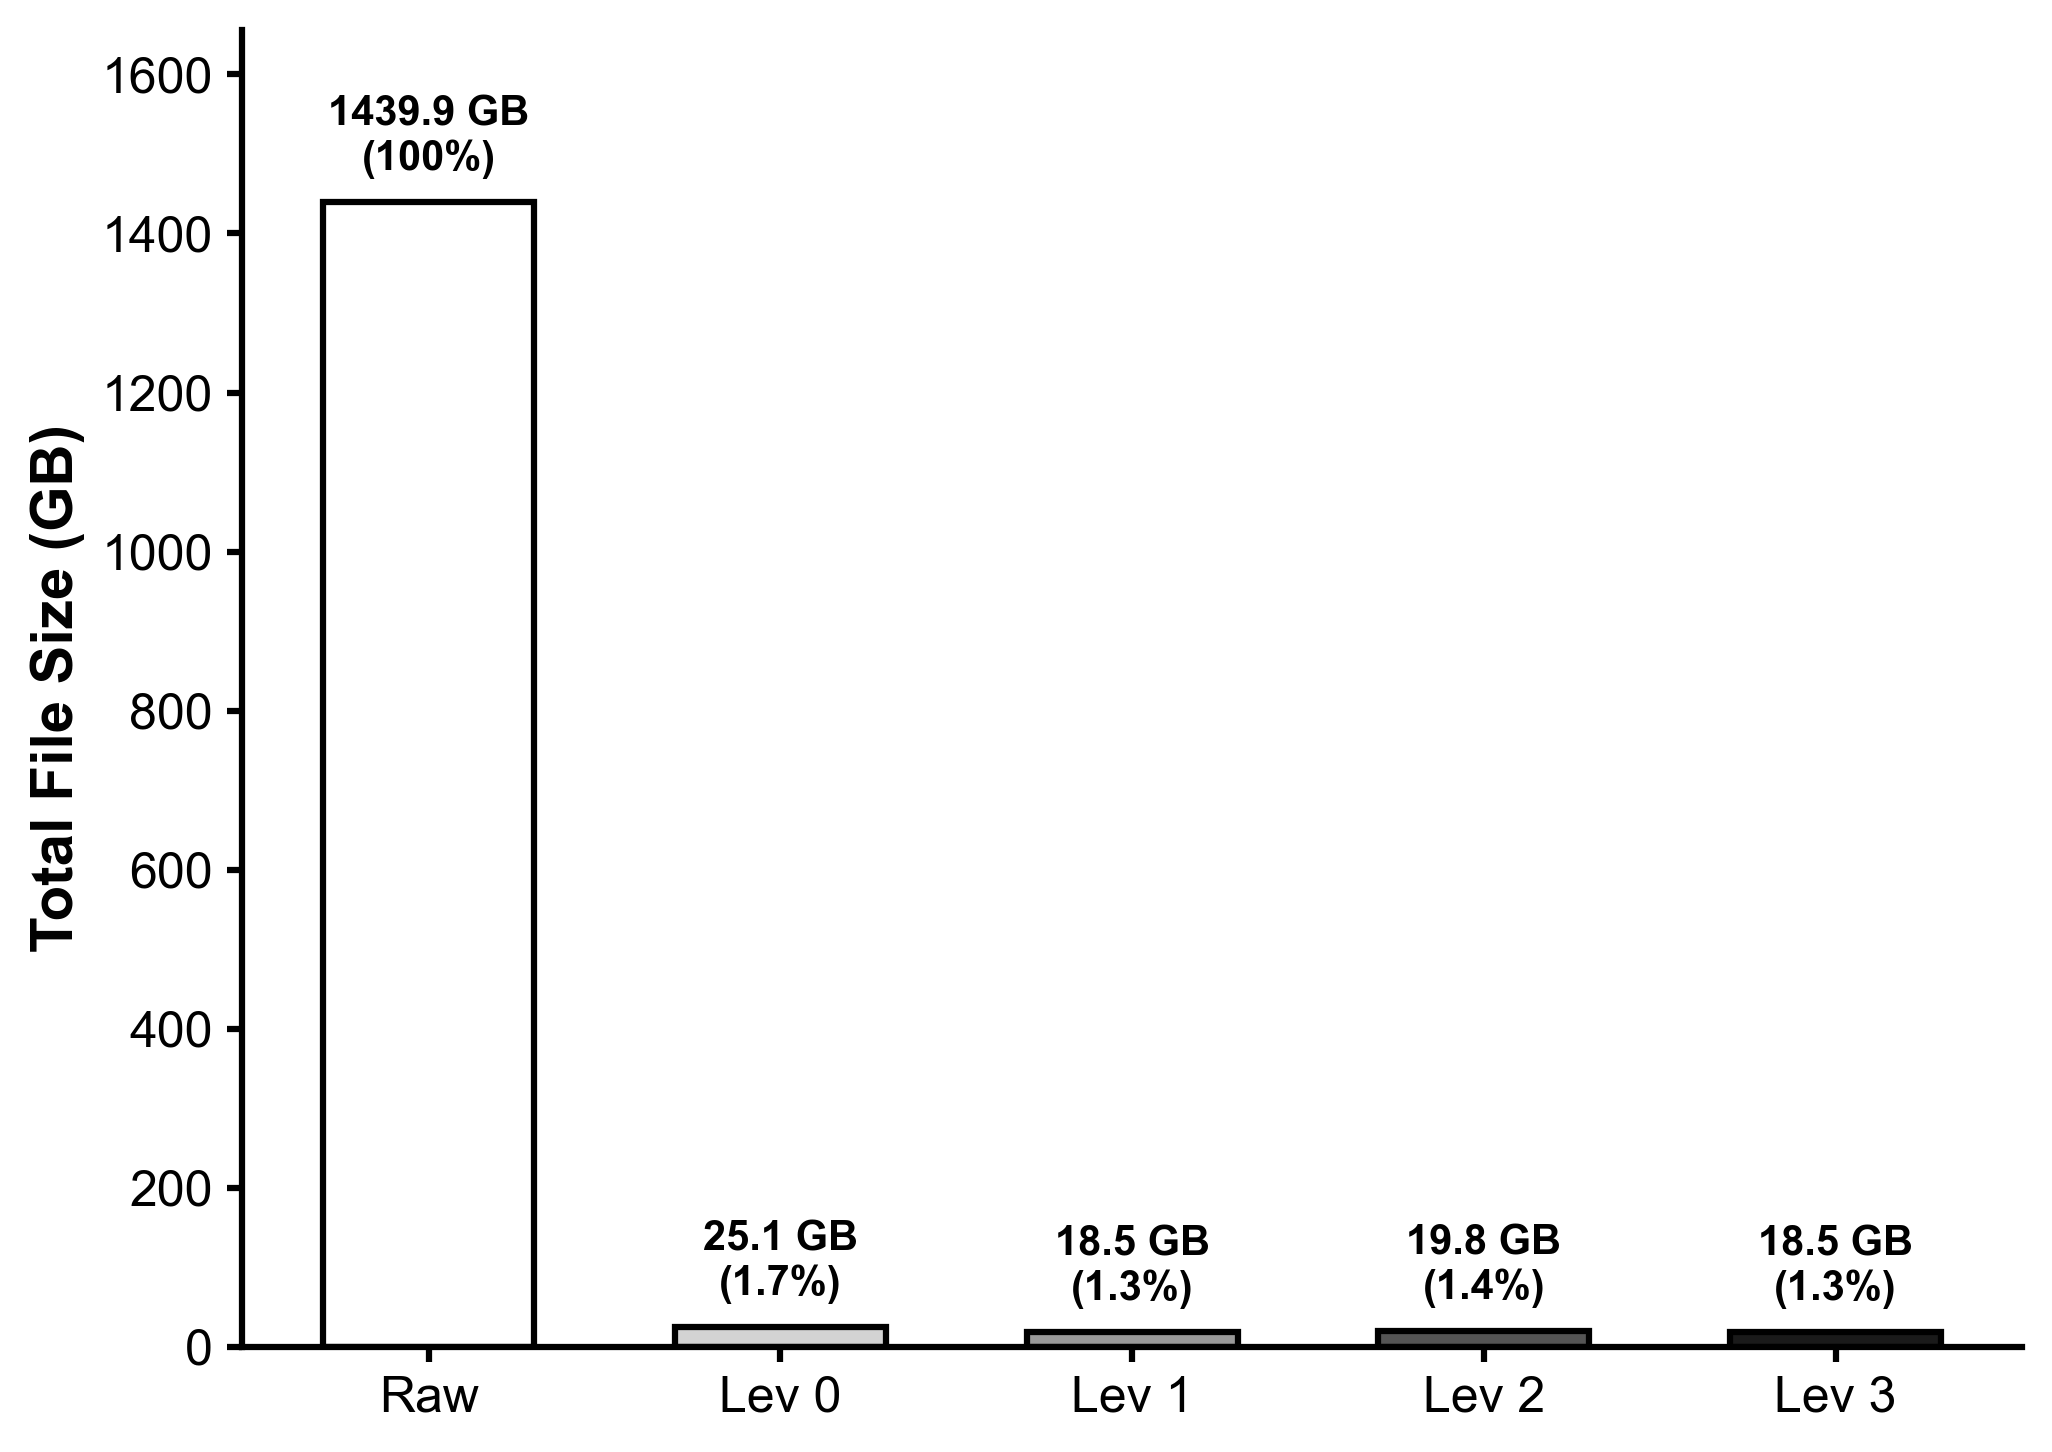

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np

from analysis_utils import get_total_size_of_files 


# --- 1. Define Paths ---
base_dir = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo"
raw_folder = os.path.join(base_dir, r"raw\Location-05\Raw Images")

comp_folders = {
    0: os.path.join(base_dir, r"sparz_0\compressed"),
    1: os.path.join(base_dir, r"sparz_1\compressed"),
    2: os.path.join(base_dir, r"sparz_2\compressed"),
    3: os.path.join(base_dir, r"sparz_3\compressed")
}

# --- 2. Calculate Sizes ---
# Raw size (DAT files only)
raw_size_bytes = get_total_size_of_files(raw_folder, ['.dat'])
raw_size_gb = raw_size_bytes / (1024**3)

# Compressed sizes
comp_extensions = ['.mp4', '.avi', '.mov', '.mkv', '.npz', '.zst']
comp_sizes_bytes = []
for level in [0, 1, 2, 3]:
    comp_sizes_bytes.append(get_total_size_of_files(comp_folders[level], comp_extensions))

comp_sizes_gb = [s / (1024**3) for s in comp_sizes_bytes]

# Combine for plotting
all_sizes_gb = [raw_size_gb] + comp_sizes_gb
percentages = [100.0] + [(s / raw_size_bytes) * 100 if raw_size_bytes > 0 else 0 for s in comp_sizes_bytes]
labels = ['Raw', 'Lev 0', 'Lev 1', 'Lev 2', 'Lev 3']

# --- 3. Publication Plotting ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# Colors: Raw is white, then Light -> Dark Gray
colors = ['#FFFFFF', '#D3D3D3', '#999999', '#555555', '#1A1A1A']

# Create bars
bars = ax.bar(labels, all_sizes_gb, color=colors, edgecolor='black', width=0.6, linewidth=1.5)

# Add text labels on top of the bars
for i, bar in enumerate(bars):
    yval = bar.get_height()
    if yval > 0:
        if i == 0:
            # For Raw, just print the GB
            text = f'{yval:.1f} GB\n(100%)'
        else:
            # For compressed, print GB and the percentage
            text = f'{yval:.1f} GB\n({percentages[i]:.1f}%)'
            
        ax.text(bar.get_x() + bar.get_width()/2, yval + (raw_size_gb * 0.02), 
                text, ha='center', va='bottom', 
                fontweight='bold', fontsize=10)

# Expand the y-axis limit slightly so the text on the highest bar doesn't get cut off
ax.set_ylim(0, raw_size_gb * 1.15)

# Formatting
ax.set_ylabel('Total File Size (GB)', fontweight='bold', fontsize=14)
# ax.set_title('SPARZ Data Compression', fontweight='bold', fontsize=16, pad=15) # Optional: usually titles are handled in the figure caption in papers

# Clean up spines (borders)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.tick_params(width=1.5)

plt.tight_layout()

# --- 4. Save the Figure ---
output_path_pdf = os.path.join(base_dir, 'Compression_Absolute_Sizes.pdf')
plt.savefig(output_path_pdf, format='pdf', transparent=True)
plt.show()

## SSIM

In [1]:
import os
import pandas as pd
from analysis_utils import calculate_ssim_dat_folder

# --- 1. Define Paths ---
base_dir = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo"
raw_folder = os.path.join(base_dir, r"raw\Location-05\Raw Images")

# Pointing to the decompressed folders as requested
decomp_folders = {
    0: os.path.join(base_dir, r"sparz_0\Location-05\Raw Images"),
    1: os.path.join(base_dir, r"sparz_1\Location-05\Raw Images"),
    2: os.path.join(base_dir, r"sparz_2\Location-05\Raw Images"),
    3: os.path.join(base_dir, r"sparz_3\Location-05\Raw Images")
}

# --- 2. Calculate SSIM and build DataFrame ---
all_results = []

for level in [0, 1, 2, 3]:
    folder = decomp_folders[level]
    if os.path.exists(folder):
        print(f"Calculating SSIM for Level {level}... (This might take a while)")
        
        # Get the list of dictionaries from our utility function
        results = calculate_ssim_dat_folder(raw_folder, folder)
        
        # Tag each result with its compression level so we can filter it later
        for res in results:
            res['compression_level'] = level
            
        all_results.extend(results)
        print(f"  -> Finished Level {level}.")
    else:
        print(f"Warning: Folder not found: {folder}")

# --- 3. Save to CSV ---
df_ssim = pd.DataFrame(all_results)

# Save it to your main figure folder
csv_path = os.path.join(base_dir, 'SSIM_Results.csv')
df_ssim.to_csv(csv_path, index=False)

print(f"\n✅ All SSIM calculations complete! Saved DataFrame to:\n{csv_path}")
df_ssim.head() # Display the first few rows just to check it

Calculating SSIM for Level 0... (This might take a while)
  -> Finished Level 0.
Calculating SSIM for Level 1... (This might take a while)
  -> Finished Level 1.
Calculating SSIM for Level 2... (This might take a while)
  -> Finished Level 2.
Calculating SSIM for Level 3... (This might take a while)
  -> Finished Level 3.

✅ All SSIM calculations complete! Saved DataFrame to:
X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo\SSIM_Results.csv


,original_file,compressed_file,ssim,compression_level
0,img000000.dat,img000000.dat,0.999936,0
1,img000001.dat,img000001.dat,0.999957,0
2,img000002.dat,img000002.dat,0.999961,0
3,img000003.dat,img000003.dat,0.999960,0
4,img000004.dat,img000004.dat,0.999958,0


C:\Users\Vutara\AppData\Local\Temp\ipykernel_10264\2385512576.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(ssim_data,


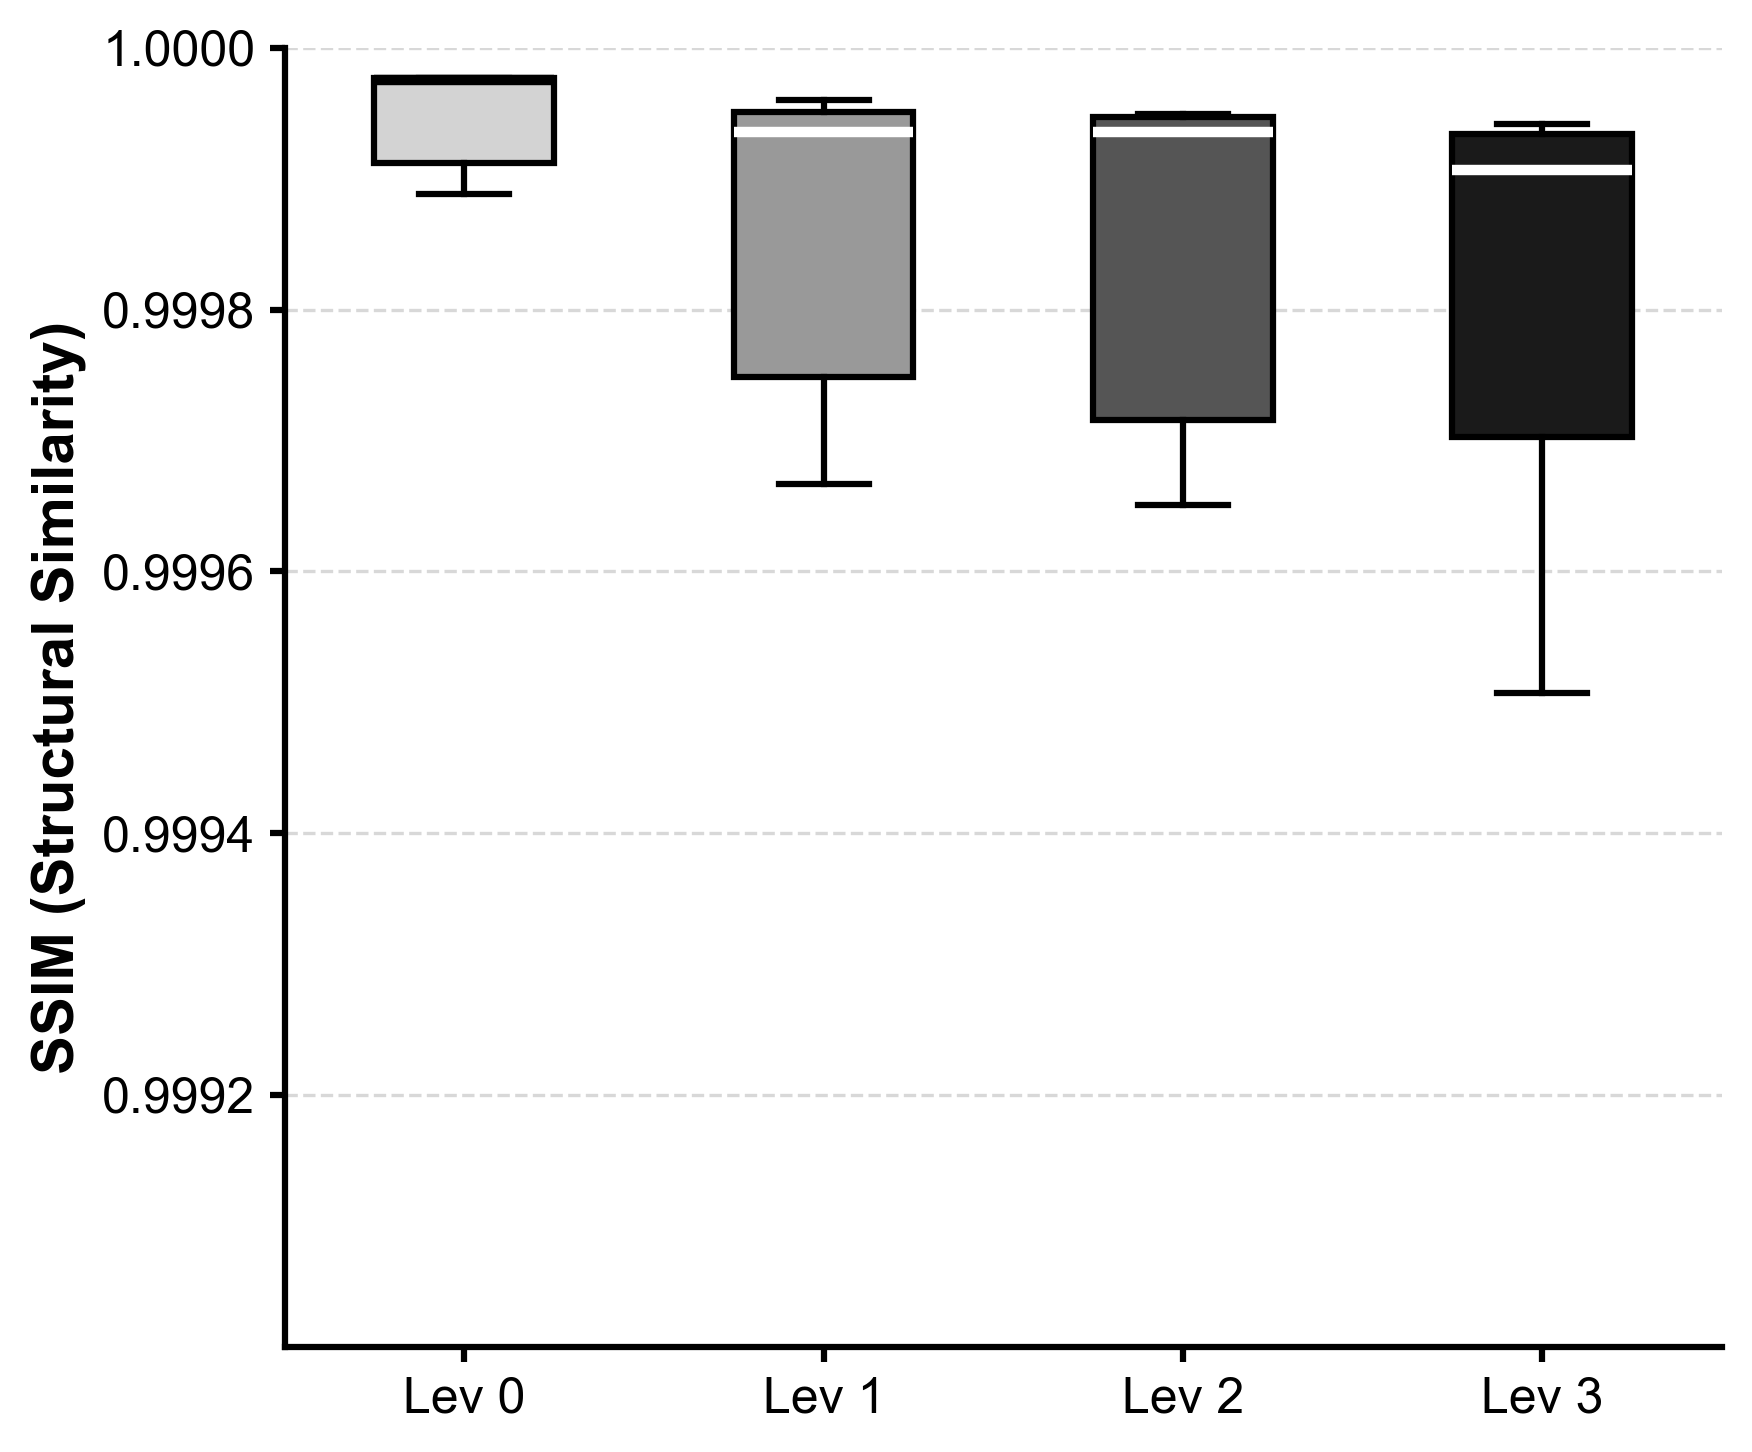

--- Median SSIM Scores ---
Level 0: 1.0000
Level 1: 0.9999
Level 2: 0.9999
Level 3: 0.9999


In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Load the Data ---
base_dir = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo"
csv_path = os.path.join(base_dir, 'SSIM_Results.csv')

df_ssim = pd.read_csv(csv_path)

# Extract the SSIM scores into a list of lists for the boxplot
ssim_data = []
labels = []

for level in [0, 1, 2, 3]:
    # Filter the dataframe for this specific level, grab the 'ssim' column, and drop NaNs
    level_scores = df_ssim[df_ssim['compression_level'] == level]['ssim'].dropna().tolist()
    
    if level_scores:
        ssim_data.append(level_scores)
        labels.append(f'Lev {level}')

# --- 2. Publication Plotting ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
colors = ['#D3D3D3', '#999999', '#555555', '#1A1A1A']

# Create the Boxplot
bplot = ax.boxplot(ssim_data, 
                   patch_artist=True,      
                   widths=0.5,             
                   labels=labels,
                   medianprops=dict(color='white', linewidth=2.5), 
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5),
                   flierprops=dict(marker='o', markerfacecolor='gray', 
                                   markeredgecolor='none', markersize=5, alpha=0.5)) 

# Apply colors and borders to the boxes
for i, patch in enumerate(bplot['boxes']):
    patch.set_facecolor(colors[i])
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)
    
    # Make the median line black for the lightest box for contrast
    if i == 0: 
        bplot['medians'][i].set_color('black')

# Formatting the Y-Axis
ax.set_ylabel('SSIM (Structural Similarity)', fontweight='bold', fontsize=14)

# Automatically zoom the Y-axis based on the lowest outlier, plus a tiny bit of padding
min_ssim = min([min(scores) for scores in ssim_data if scores])
# We cap the bottom at 0.0 to prevent it from going negative if the math gets weird
ax.set_ylim(max(0.0, min_ssim - 0.0005), 1.000)  

# Clean up spines (borders)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.tick_params(width=1.5)

# Add a subtle grid behind the boxes
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
ax.set_axisbelow(True) 

plt.tight_layout()

# --- 3. Save the Figure ---
output_path_pdf = os.path.join(base_dir, 'Compression_SSIM_Boxplot.pdf')
plt.savefig(output_path_pdf, format='pdf', transparent=True)
plt.show()

# Print medians to the console for your manuscript text
print("--- Median SSIM Scores ---")
for i, level in enumerate([0, 1, 2, 3]):
    if i < len(ssim_data):
        print(f"Level {level}: {np.median(ssim_data[i]):.4f}")

## Show the npz cutouts

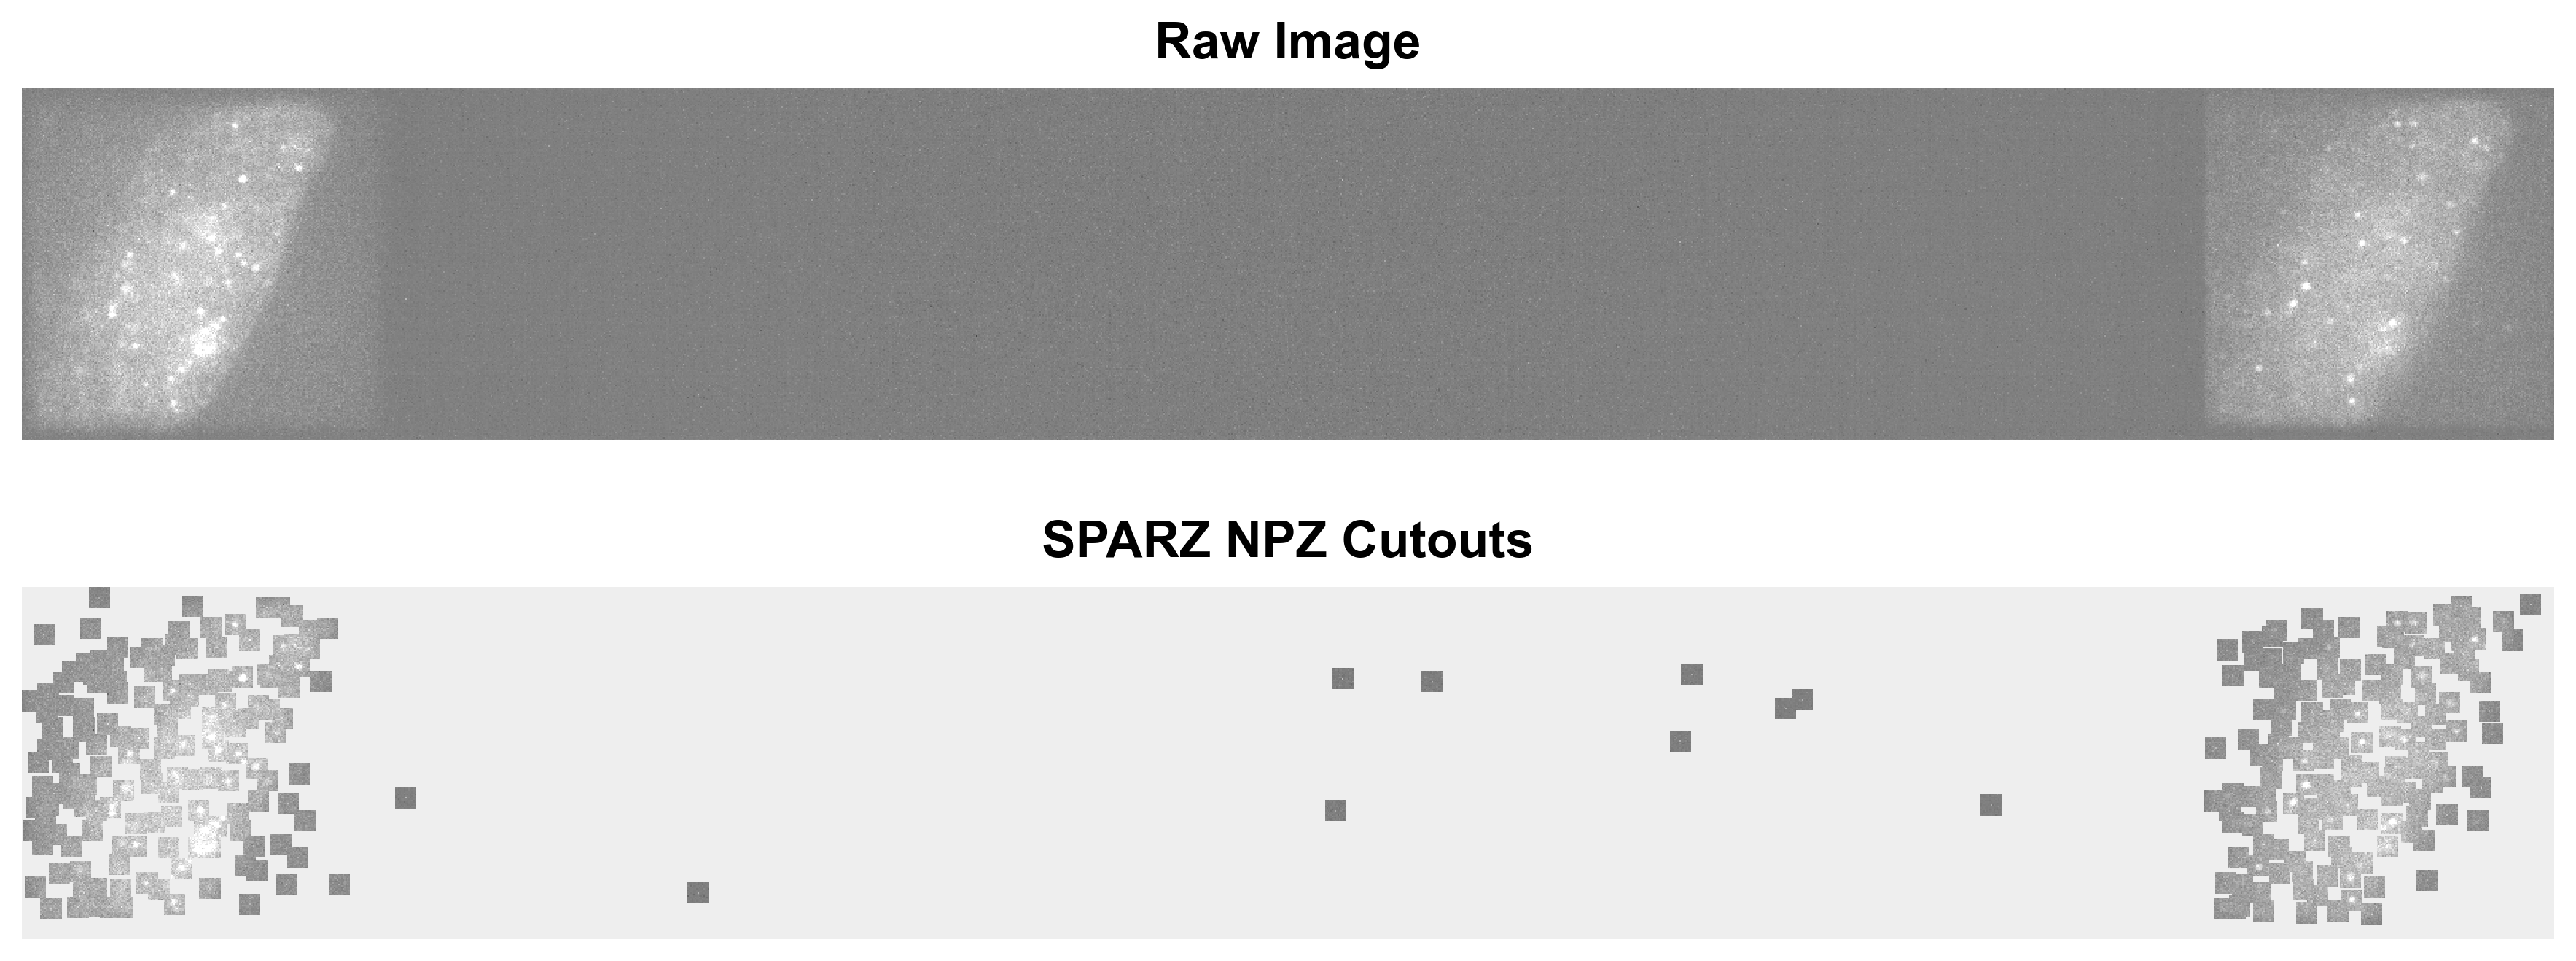

NPZ Frame 100: Kept 57461 pixels out of 442432 (12.99%)


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from SPARZ import UNSPARZ

# --- 1. Define Paths ---
base_dir = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo"
raw_file = os.path.join(base_dir, r"raw\Location-05\Raw Images\img000000.dat")
# Point this directly to the .npz file created during compression
npz_file = os.path.join(base_dir, r"sparz_0\compressed\img000000.npz") 

frame_idx = 100  # The frame you want to inspect

# --- 2. Load NPZ Data First (To get the absolute correct shape) ---
u = UNSPARZ.__new__(UNSPARZ) 
sparse_matrix = u.load_sparse_matrix_from_npz(npz_file)

# Extract our specific frame
cutout_img = sparse_matrix[frame_idx].todense()

# Get the exact dimensions that SPARZ originally used!
H, W = cutout_img.shape

# --- 3. Load Raw .dat frame using the verified shape ---
# We use numpy memmap, which is exactly how SPARZIP reads the files internally
raw_data = np.memmap(raw_file, dtype='uint16', mode='r')
pixels_per_frame = H * W

# Extract our specific frame's bytes and reshape it to match the NPZ perfectly
raw_img = raw_data[frame_idx * pixels_per_frame : (frame_idx + 1) * pixels_per_frame].reshape(H, W)

# --- 4. Publication Plotting ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14

# Change to 2 rows, 1 column. Made the figsize taller to fit them stacked.
fig, axs = plt.subplots(2, 1, figsize=(12, 5), dpi=300)

# Set image contrast limits based on the raw image
vmax = np.percentile(raw_img, 99.9)

# YOUR TRICK: Set color for background values to #eeeeee
cmap_cutout = plt.cm.gray.copy()
cmap_cutout.set_under('#eeeeee') 

# Plot 1: Raw Image (TOP)
axs[0].imshow(raw_img, cmap='gray', vmin=0, vmax=vmax, interpolation='none')
axs[0].set_title('Raw Image', fontweight='bold', pad=10)
axs[0].axis('off')

# Plot 2: Cutout Image (BOTTOM)
# We use vmin=1 so that the empty background 0s trigger the 'under' color (#eeeeee)
axs[1].imshow(cutout_img, cmap=cmap_cutout, norm=mcolors.Normalize(vmin=1, vmax=vmax), interpolation='none')
axs[1].set_title('SPARZ NPZ Cutouts', fontweight='bold', pad=10)
axs[1].axis('off')

plt.tight_layout()

# Save the plot
output_path_pdf = os.path.join(base_dir, 'NPZ_Cutout_Visualization_Stacked.pdf')
plt.savefig(output_path_pdf, format='pdf')
plt.show()

# Optional: Print out how many non-zero pixels are actually saved in this frame
non_zero = np.count_nonzero(cutout_img)
total_pixels = cutout_img.size
print(f"NPZ Frame {frame_idx}: Kept {non_zero} pixels out of {total_pixels} ({(non_zero/total_pixels)*100:.2f}%)")

## Overview images from grid search

In [5]:
# Define the parameters used in grid search
kernel_sizes = [7,9,11,13]  
rel_thresholds = [0.25, 0.35, 0.45, 0.55]  
compression_levels = [0, 1, 2, 3]  

In [6]:
# Reconstruction of the full array from the sparse data
def reconstruct_array(data):
    shape = tuple(data['shape'])
    fill_value = data['fill_value']
    coords = data['coords']
    sparse_data = data['data']

    full_array = np.full(shape, fill_value)
    for i, coord in enumerate(zip(*coords)):
        full_array[coord] = sparse_data[i]
    return full_array

# Load and plot the npz files
def load_and_plot_npz_files(folder_path, compression_level=0):
    # Double the number of columns to accommodate two images per condition
    fig, axs = plt.subplots(len(kernel_sizes), len(rel_thresholds) * 2, figsize=(15, 10))

    for root, dirs, files in os.walk(folder_path):
        for dir in dirs:
            kernel_size, rel_threshold, comp_level = extract_parameters(dir)

            if comp_level == compression_level:
                if kernel_size in kernel_sizes and rel_threshold in rel_thresholds:
                    file_paths = ['img_01_01_bp1.npz', 'img_01_01_bp2.npz']
                    for index, file_name in enumerate(file_paths):
                        file_path = os.path.join(root, dir, file_name)
                        if os.path.exists(file_path):
                            data = np.load(file_path)
                            full_array = reconstruct_array(data)
                            selected_image = full_array[25]

                            # Find the correct subplot
                            i = kernel_sizes.index(kernel_size)
                            j = rel_thresholds.index(rel_threshold) * 2 + index

                            # Set color for values below the colormap range
                            cmap = plt.cm.gray
                            cmap.set_under('#eeeeee')

                            # Plot the selected image
                            axs[i, j].imshow(selected_image, cmap=cmap, interpolation='none', norm=mcolors.Normalize(vmin=0.1, vmax=np.max(selected_image)))
                            axs[i, j].axis('off')

                            # Set title for the first image of the pair
                            # if index == 0:
                            #     axs[i, j].set_title(f'k{kernel_size} thr{rel_threshold}')
   

    plt.tight_layout()

      # Save the plot as a PDF
    plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/npz_profiles_figure3_nir.pdf', format='pdf')  

    plt.show()

# Extract the parameters from the folder name after the grid search
def extract_parameters(folder_name):
    match = re.search(r'k(\d+)_rt(\d+)_lev(\d+)', folder_name)
    if match:
        kernel_size = int(match.group(1))
        rel_threshold = float(f"0.{match.group(2)}")
        compression_level = int(match.group(3))
        return kernel_size, rel_threshold, compression_level
    else:
        return None, None, None

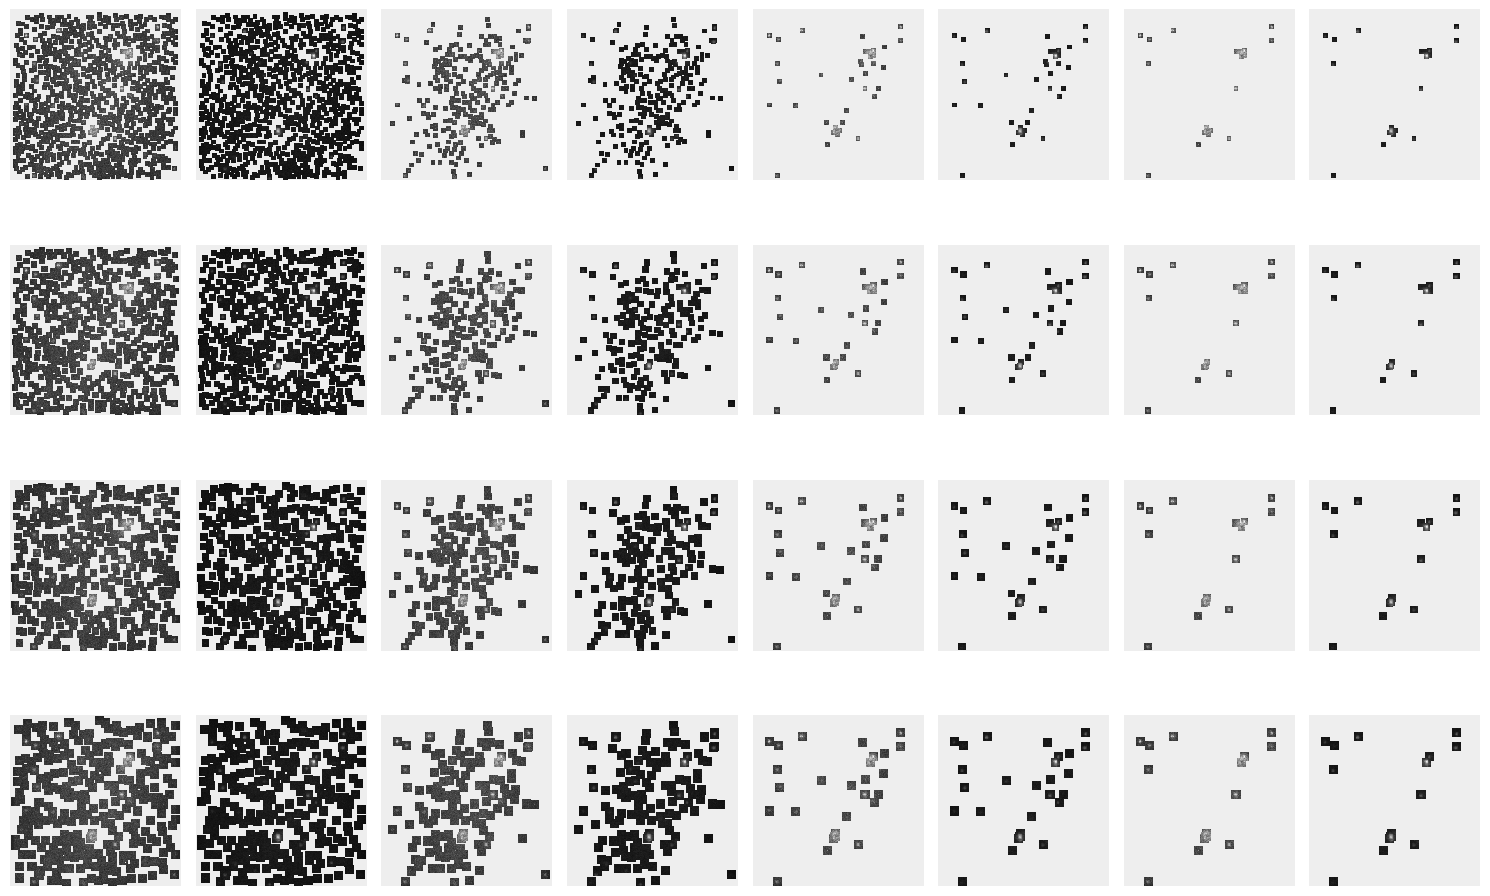

In [8]:

main_folder_path = "/Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_3_data/grid_search"
# Load and plot
load_and_plot_npz_files(main_folder_path)

# Image comparison - SSIM

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
csv_file = '/Users/laurabreimann/Desktop/nir_ssim.csv'
ssim_single_df = pd.read_csv(csv_file)

# Specify the folders you want to include in the plot
selected_folders = ['sparz_k7_rt55_lev0','sparz_k7_rt55_lev1', 'sparz_k7_rt55_lev2',  'sparz_k7_rt55_lev3']

# Filter the DataFrame for the selected folders
filtered_df = ssim_single_df[ssim_single_df['Folder'].isin(selected_folders)]

# Prepare the raw image data
raw_image_data = pd.DataFrame({
    'Folder': ['Raw Image'],
    'percentage_size': [100.0],
    'SSIM': [1.0]
})

# Add the raw image data to the filtered DataFrame
combined_df = pd.concat([filtered_df, raw_image_data])

# Prepare data for plotting
data_for_plotting = []
positions = []

for folder in selected_folders + ['Raw Image']:
    folder_data = combined_df[combined_df['Folder'] == folder]['SSIM']
    folder_size = combined_df[combined_df['Folder'] == folder]['percentage_size'].mean()
    data_for_plotting.append(folder_data)
    positions.append(folder_size)

# Plotting
plt.figure(figsize=(10, 7))
plt.boxplot(data_for_plotting, positions=positions, widths=5, patch_artist=True, showfliers=False)

plt.xlabel('File Size Percentage')
plt.ylabel('SSIM')
plt.ylim(0.97, 1.002)
plt.xlim(10, 105)
plt.title('Comparison of File Size and SSIM')

# Customizing the plot appearance
plt.grid(False)  # Remove the background lines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Round x-axis tick labels to the nearest integer
plt.xticks(ticks=np.round(plt.gca().get_xticks()), labels=np.round(plt.gca().get_xticks()).astype(int))

#Save the plot as PDF
plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/SSIM_Figure3b.pdf')    

plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/Users/laurabreimann/Desktop/nir_ssim.csv'

# Figure 3 SPARZ paper images
# Convert .h5r localization files to .csv


In [27]:
# Function to read .h5r files
from h5r_functions import h5r_to_df
from glob import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors


In [28]:
# loop through all folders and extract the file paths
main_folder = "/Volumes/X10/1.Projects/HMS/SPARZ/figure_3_data/localizations"
h5r_files = glob(f"{main_folder}/*/*/*.h5r", recursive=True)

# extract the condition names
conditions = [os.path.basename(os.path.dirname(os.path.dirname(file))).split('_')[-1].replace('lev', 'level_') for file in h5r_files]

# create a folder to save the csv files
if not os.path.exists(f"{main_folder}/csv/"):
    os.makedirs(f"{main_folder}/csv/")

# read each file and save as csv
for file, condition in zip(h5r_files, conditions):
    print(file)
    df = h5r_to_df(file)
    df = df.rename(columns={"fitResults_x0": "x", "fitResults_y0": "y", "fitResults_z0": "z"})
    df.to_csv(f"{main_folder}/csv/{condition}.csv", index=False)



# Localization comparison - Jaccard

In [6]:
# Function for 3D Jaccard index of two point clouds
def pointcloud_to_voxels(data, voxel_size):
    """
    Convert point cloud data to a set of occupied voxels.
    
    Parameters:
    - data: DataFrame or numpy array containing x, y, z coordinates.
    - voxel_size: The size of the voxel used for binning the points.
    
    Returns:
    - A set of tuples representing the occupied voxel indices.
    """
    # Compute voxel indices for each point
    voxel_indices = (data / voxel_size).astype(int)
    
    # Convert to set for unique voxel indices
    occupied_voxels = set(map(tuple, voxel_indices.values))
    
    return occupied_voxels

def compute_jaccard_similarity_manual(u, v, voxel_size=0.5):
    """
    Compute the Jaccard Similarity between two sets of points using manual voxelization and alternative intersection computation.
    """
    
    # Convert dataframes to voxel sets
    set_u = pointcloud_to_voxels(u, voxel_size)
    set_v = pointcloud_to_voxels(v, voxel_size)
    
    # Compute intersection using an alternative method
    intersection_count = len(set_u.intersection(set_v))
    union_count = len(set_u.union(set_v))
    
    return intersection_count / union_count if union_count != 0 else 0.0

# nearest neighbors function
def compute_nearest_neighbours(df1, df2, n_neighbors=1, algorithm='ball_tree'):
    # Determine the number of rows in each dataframe
    len_df1 = len(df1)
    len_df2 = len(df2)

    print(f"Original lengths: df1={len_df1}, df2={len_df2}")

    # If the dataframes have different number of rows
    if len_df1 != len_df2:
        # Determine which dataframe is smaller
        if len_df1 < len_df2:
            # Pad df1 with dummy rows
            df1 = pd.concat([df1, pd.DataFrame(np.zeros((len_df2 - len_df1, df1.shape[1])), columns=df1.columns)], ignore_index=True)
        else:
            # Pad df2 with dummy rows
            df2 = pd.concat([df2, pd.DataFrame(np.zeros((len_df1 - len_df2, df2.shape[1])), columns=df2.columns)], ignore_index=True)

    print(f"Padded lengths: df1={len(df1)}, df2={len(df2)}")

    # Compute the nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm=algorithm).fit(df1)
    distances, indices = nbrs.kneighbors(df2)

    print(f"Distances and indices lengths: distances={len(distances)}, indices={len(indices)}")

    # If df1 was padded, remove the dummy rows from the indices
    if len_df1 < len_df2:
        indices = indices[:len_df1]
    # If df2 was padded, remove the dummy rows from the distances and indices
    elif len_df1 > len_df2:
        distances = distances[:len_df2]
        indices = indices[:len_df2]

    print(f"Final lengths: distances={len(distances)}, indices={len(indices)}")

    return distances, indices


In [ ]:
# Read raw file
csv_folder = "/Volumes/X10/1.Projects/HMS/SPARZ/figure_3_data/localizations/csv/15_50_100_0_06/" 
raw_file = (glob(f"{csv_folder}/raw*clusters_FILTERED.csv"))
# raw_file = [file for file in csv_files if 'raw.csv' in file][0]
raw_df = pd.read_csv(raw_file[0])
# create raw rand and save to disk

# the following line will crop the localizations 
raw_df_f = raw_df[(raw_df.x > 13800) & (raw_df.x < 15800) & (raw_df.y > 9000) & (raw_df.y < 11000)]

# The following line will NOT crop the localizations and will show the hole dataset as shown in the supplumments
# raw_df_f = raw_df.copy()

raw_rand = raw_df_f[['x','y','z']] + np.random.normal(0, 300, raw_df_f[['x','y','z']].shape)
raw_rand.to_csv(csv_folder+'/raw_rand.csv', index=False)

In [ ]:
# Read in the CSV files that are filtered for background localizations
# csv_files = glob(f"{csv_folder}/level_[0-9]*clusters_FILTERED.csv")
# csv_files = csv_files + (glob(f"{csv_folder}/raw*clusters_FILTERED.csv"))
# csv_files = csv_files + (glob(f"{csv_folder}/raw_rand.csv"))


# Read the CSV files that are not filtered
csv_folder = "/Volumes/X10/1.Projects/HMS/SPARZ/figure_3_data/localizations/csv/" 
csv_files = glob(f"{csv_folder}/level_[0-9].csv")
csv_files = csv_files + (glob(f"{csv_folder}raw.csv"))
csv_folder = "/Volumes/X10/1.Projects/HMS/SPARZ/figure_3_data/localizations/csv/15_50_100_0_06" 
csv_files = csv_files + (glob(f"{csv_folder}/raw_rand.csv"))
voxel_size = 40
csv_files.sort()
csv_files


['/Volumes/X10/1.Projects/HMS/SPARZ/figure_3_data/localizations/csv/15_50_100_0_06/raw_rand.csv',
 '/Volumes/X10/1.Projects/HMS/SPARZ/figure_3_data/localizations/csv/level_0.csv',
 '/Volumes/X10/1.Projects/HMS/SPARZ/figure_3_data/localizations/csv/level_1.csv',
 '/Volumes/X10/1.Projects/HMS/SPARZ/figure_3_data/localizations/csv/level_2.csv',
 '/Volumes/X10/1.Projects/HMS/SPARZ/figure_3_data/localizations/csv/level_3.csv',
 '/Volumes/X10/1.Projects/HMS/SPARZ/figure_3_data/localizations/csv/raw.csv']

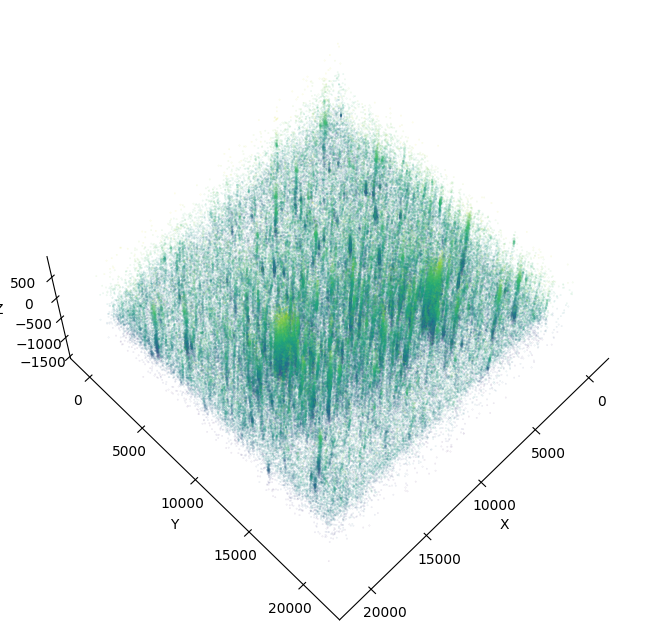

In [21]:
elev=70
azim=45
size = 0.05
# Run analysis on nn distances and Jaccard index

# Filter raw data once
raw_file_path = next(f for f in csv_files if f.endswith('raw.csv'))
raw_df_f = pd.read_csv(raw_file_path)
# raw_df_f = raw_df#[(raw_df.x > 13800) & (raw_df.x < 15800) & (raw_df.y > 9000) & (raw_df.y < 11000)].copy()

# Pre-compute z-range for raw data
raw_z_min, raw_z_max = raw_df_f.z.min(), raw_df_f.z.max()
raw_z_range = raw_z_max - raw_z_min if raw_z_max != raw_z_min else 1





# Create 3D plot for raw data
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create 3D scatter plot
scatter = ax.scatter(raw_df_f.x, raw_df_f.y, raw_df_f.z, 
                    c=raw_df_f.z, 
                    s=size, 
                    alpha=0.2,
                    cmap='viridis')

# Set axis limits and labels
# ax.set_xlim(13800, 15800)
# ax.set_ylim(9000, 11000)
# ax.set_zlim(-1500, 1000)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Remove gray background and set custom ticks
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('white')
ax.yaxis.pane.set_edgecolor('white')
ax.zaxis.pane.set_edgecolor('white')
ax.grid(False)

# Set custom tick intervals (every 500)
# ax.set_xticks(np.arange(14000, 16000, 500))
# ax.set_yticks(np.arange(9000, 11500, 500))

# Set viewing angle
ax.view_init(elev=elev, azim=azim)
plt.show()


raw_rand


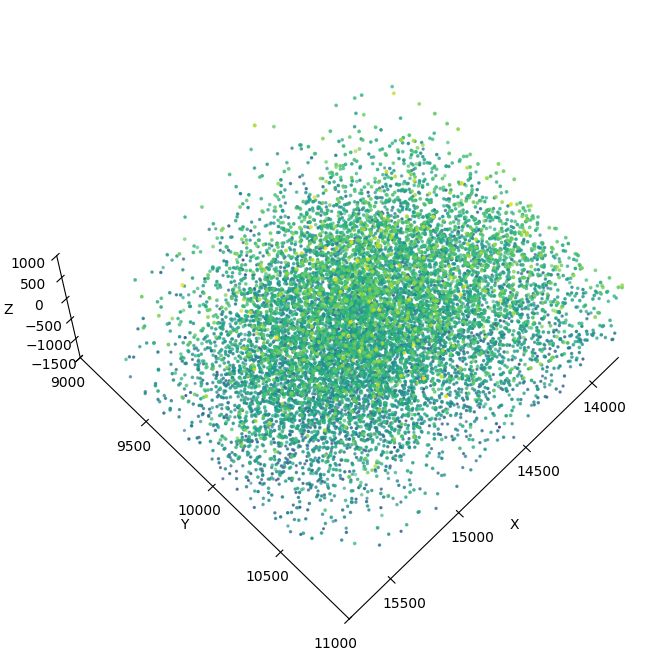

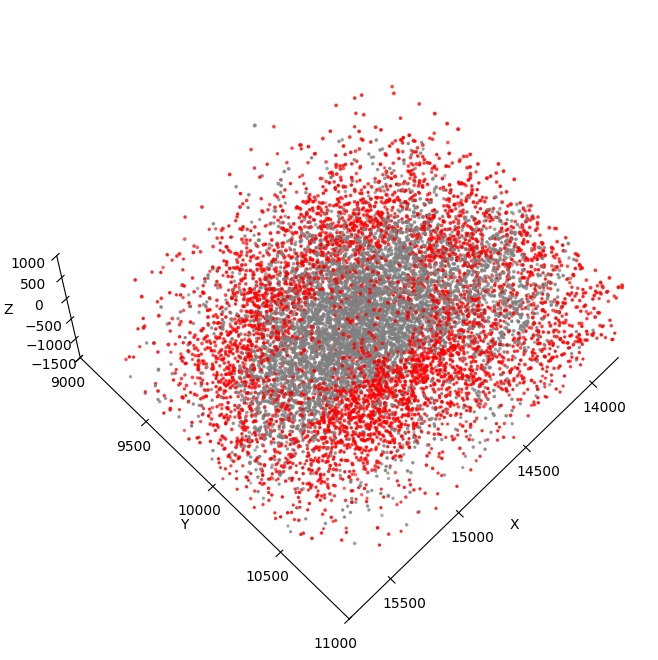

level_0


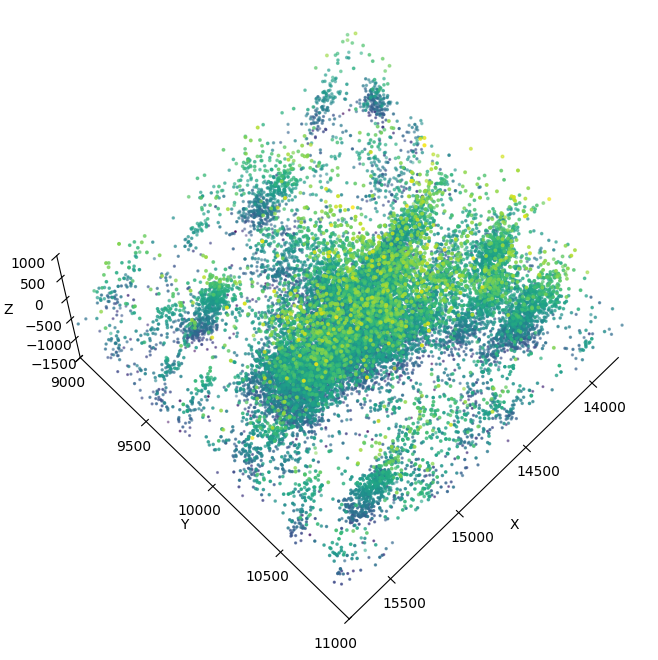

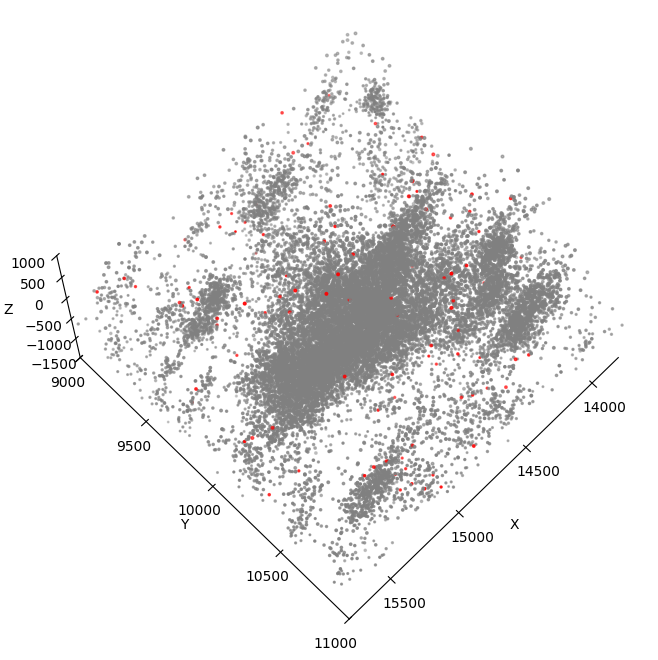

level_1


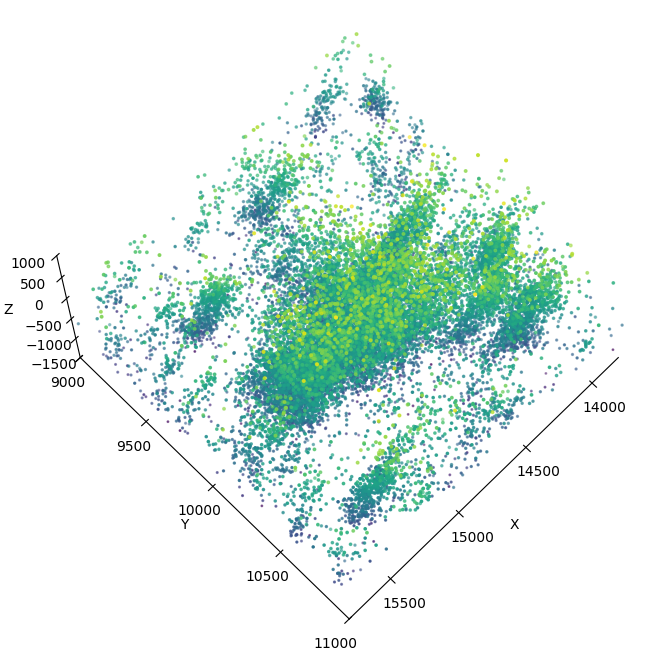

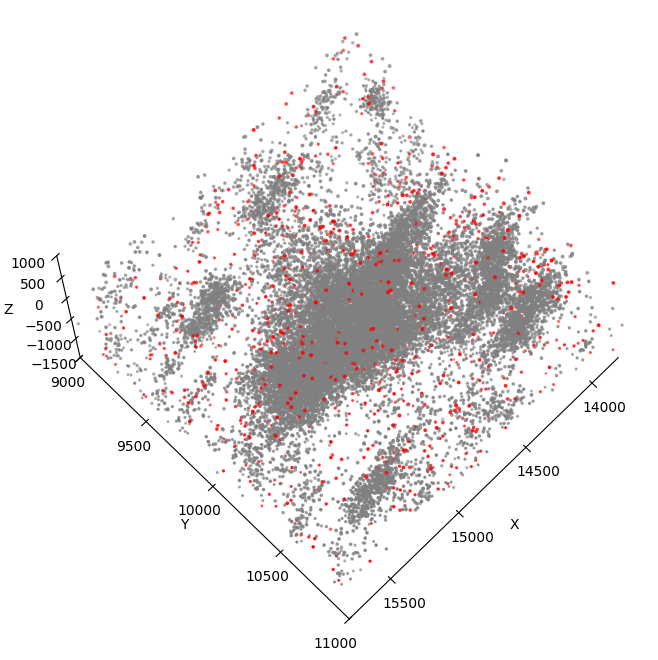

level_2


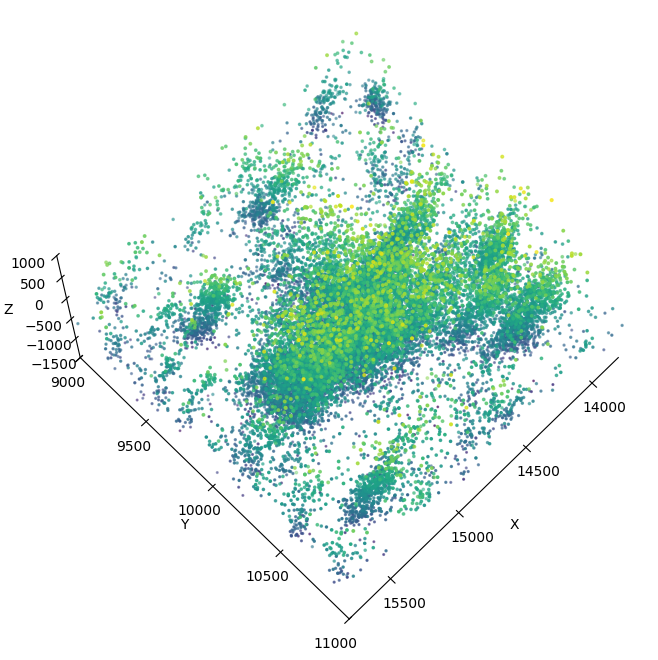

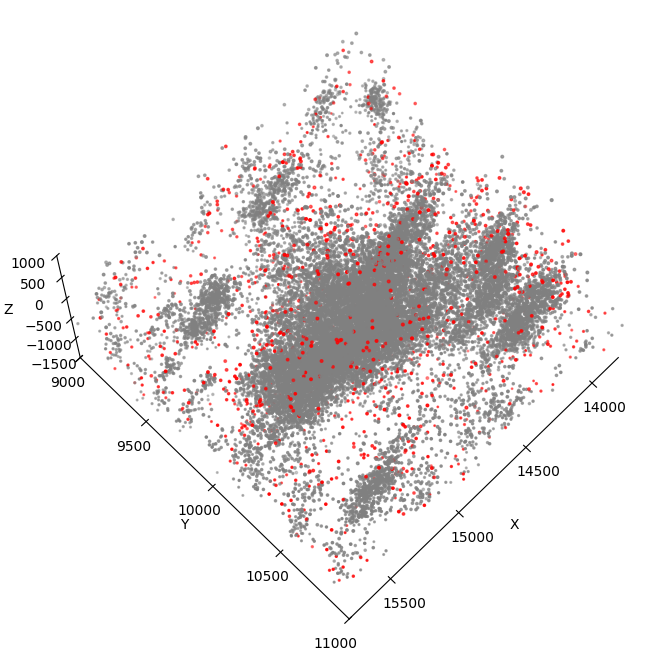

level_3


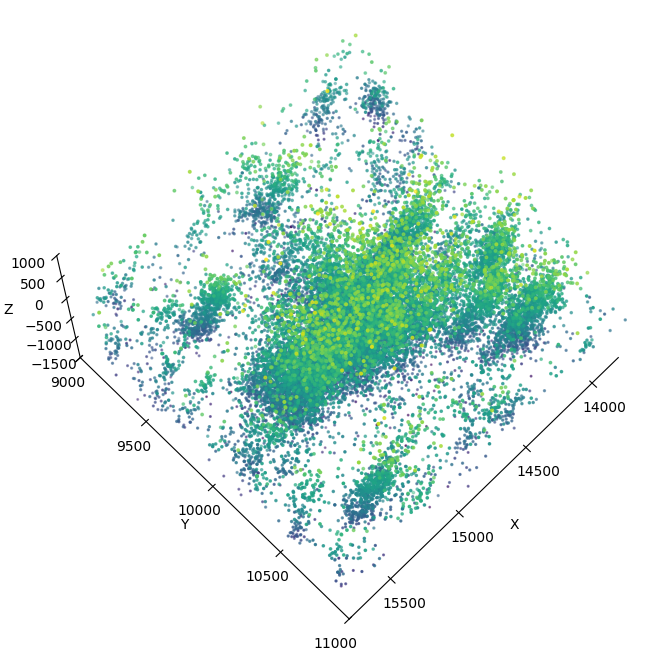

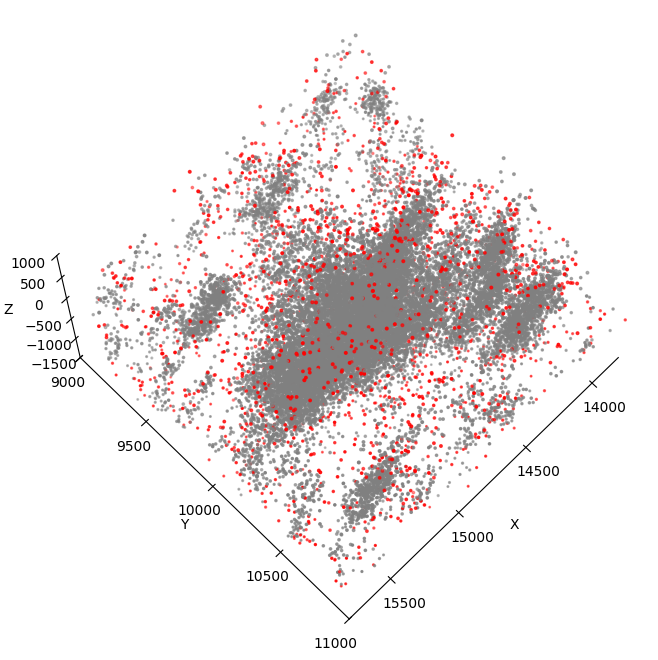

raw


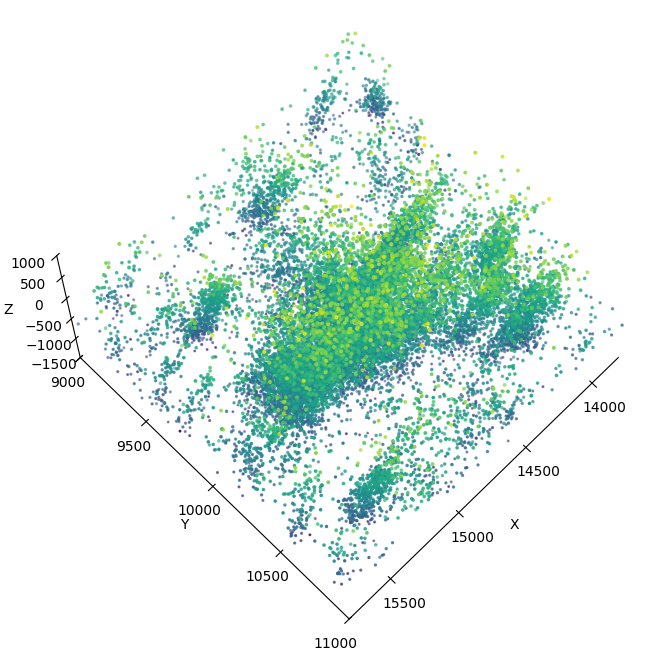

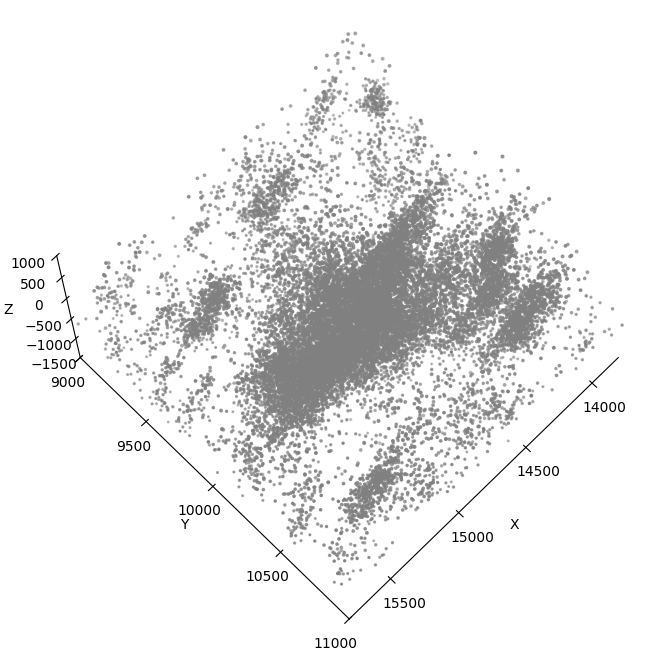

[{'file': 'raw_rand',
  'jaccard': 0.011505572441742655,
  'distances': array([ 16.3806665 ,  36.43394921,  63.78708579, ...,  25.29463617,
         123.71137447, 109.98057055], shape=(11397,))},
 {'file': 'level_0',
  'jaccard': 0.04990359910553295,
  'distances': array([0.03856152, 0.18322364, 0.08067696, ..., 0.06897051, 0.06023178,
         0.11407097], shape=(20311,))},
 {'file': 'level_1',
  'jaccard': 0.04173265366722756,
  'distances': array([3.17217554, 3.80887235, 9.14150449, ..., 0.52628731, 0.77905056,
         2.94722961], shape=(21826,))},
 {'file': 'level_2',
  'jaccard': 0.03973621635853512,
  'distances': array([12.10630132,  1.33700682,  2.32339366, ...,  5.77101461,
          2.1012766 ,  1.27385322], shape=(22455,))},
 {'file': 'level_3',
  'jaccard': 0.03460923539922882,
  'distances': array([18.36595632, 10.02056457, 11.1563633 , ..., 23.59054652,
         51.04579891,  6.31290724], shape=(23373,))},
 {'file': 'raw',
  'jaccard': 0.05204065454484767,
  'distances'

In [29]:
elev=70
azim=45

# Read the rest of the files
files = [file for file in csv_files]

# Pre-extract raw data for nearest neighbor computation
raw_xyz = raw_df_f[['x', 'y', 'z']].values

# Pre-fit nearest neighbors model for efficiency
nbrs = NearestNeighbors(n_neighbors=1, algorithm='kd_tree', n_jobs=-1).fit(raw_xyz)

# loop through all files and calculate the Jaccard index between the raw and the rest of the files
jaccard_results = []
for file in files:
    df = pd.read_csv(file)
    # filter df x should be between 13800 and 15800 and y should be between 9000 and 11000
    df_f = df[(df.x > 13800) & (df.x < 15800) & (df.y > 9000) & (df.y < 11000)].copy()
    file_name = file.split('/')[-1].split('.')[0]
    print(file_name)
    
    # Pre-compute z-range for interpolation
    z_min, z_max = df_f.z.min(), df_f.z.max()
    z_range = z_max - z_min if z_max != z_min else 1

    # Size per-point for this filtered df
    size = 1 + 3 * (df_f.z - z_min) / z_range
    
    # Create 3D scatter plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(df_f.x, df_f.y, df_f.z, 
                        c=df_f.z, 
                        s=size,  # Optimized size calculation
                        alpha=0.3 + 0.7 * (df_f.z - z_min) / z_range,  # Optimized alpha calculation
                        cmap='viridis')

    # Set axis limits and labels
    ax.set_xlim(13800, 15800)
    ax.set_ylim(9000, 11000)
    ax.set_zlim(-1500, 1000)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # Remove gray background and set custom ticks
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('white')
    ax.yaxis.pane.set_edgecolor('white')
    ax.zaxis.pane.set_edgecolor('white')
    ax.grid(False)

    # Set custom tick intervals (every 500)
    ax.set_xticks(np.arange(14000, 16000, 500))
    ax.set_yticks(np.arange(9000, 11500, 500))

    # Set viewing angle
    ax.view_init(elev=elev, azim=azim)
    plt.show()

    # Optimized nearest neighbor computation
    df_xyz = df_f[['x', 'y', 'z']].values
    
    # Use pre-fitted nearest neighbor model
    distances, indices = nbrs.kneighbors(df_xyz)
    distances = distances.flatten()
    
    # Compute Jaccard similarity
    jaccard_to_append = compute_jaccard_similarity_manual(
        pd.DataFrame(raw_xyz, columns=['x', 'y', 'z']), 
        df_f[['x', 'y', 'z']], 
        voxel_size=voxel_size
    )
    jaccard_results.append({'file': file_name, 'jaccard': jaccard_to_append, 'distances': distances})

    # Add distance information to dataframe
    df_f['distances'] = distances
    df_f['colors'] = np.where(df_f['distances'] < 40, 'grey', 'red')

    # Plot the df with localizations < 40 in grey and localizations > 40 in red
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Create 3D scatter plot with color-coded distances
    scatter = ax.scatter(df_f.x, df_f.y, df_f.z, 
                        c=df_f.colors, 
                        s=size,  # Optimized size calculation
                        alpha=0.3 + 0.7 * (df_f.z - z_min) / z_range)  # Optimized alpha calculation
    
    # Set axis limits and labels
    ax.set_xlim(13800, 15800)
    ax.set_ylim(9000, 11000)
    ax.set_zlim(-1500, 1000)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    # Remove gray background and set custom ticks
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('white')
    ax.yaxis.pane.set_edgecolor('white')
    ax.zaxis.pane.set_edgecolor('white')
    ax.grid(False)

    # Set custom tick intervals (every 500)
    ax.set_xticks(np.arange(14000, 16000, 500))
    ax.set_yticks(np.arange(9000, 11500, 500))
    
    # Set viewing angle
    ax.view_init(elev=elev, azim=azim)
    plt.show()

jaccard_results

In [124]:
jaccard_resultsdf = pd.DataFrame(jaccard_results)
jaccard_resultsdf


,file,jaccard,distances
0,raw_rand,0.154353,"[[164.16002961080912], [233.81734116953558], [..."
1,level_0,0.955579,"[[0.9682355825138464], [0.01796881634243867], ..."
2,level_1,0.776222,"[[27.464941733181032], [0.7323007968547757], [..."
3,level_2,0.737507,"[[29.80076810156717], [1.273248284070469], [20..."
4,level_3,0.660448,"[[4.008162671401692], [0.3683411026449752], [1..."
5,raw,1.000000,"[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0...."


In [125]:
jaccard_results

[{'file': 'raw_rand',
  'jaccard': 0.15435346424601704,
  'distances': array([[164.16002961],
         [233.81734117],
         [330.31514798],
         ...,
         [ 33.67673014],
         [235.90759494],
         [ 19.98095025]])},
 {'file': 'level_0',
  'jaccard': 0.9555786916536526,
  'distances': array([[0.96823558],
         [0.01796882],
         [0.0098877 ],
         ...,
         [0.15524792],
         [0.02446353],
         [0.04831333]])},
 {'file': 'level_1',
  'jaccard': 0.7762216471304613,
  'distances': array([[27.46494173],
         [ 0.7323008 ],
         [ 0.32853523],
         ...,
         [ 1.23529332],
         [ 1.08359601],
         [ 0.16958992]])},
 {'file': 'level_2',
  'jaccard': 0.7375073486184597,
  'distances': array([[29.8007681 ],
         [ 1.27324828],
         [20.90757032],
         ...,
         [15.75436322],
         [ 0.27058765],
         [20.07297645]])},
 {'file': 'level_3',
  'jaccard': 0.6604477611940298,
  'distances': array([[ 4.008162

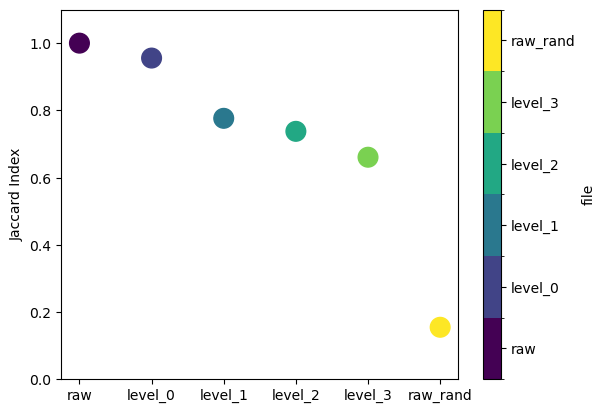

In [126]:
# make df
jaccard_resultsdf = pd.DataFrame(jaccard_results)

# Sort 
order = ['raw', 'level_0', 'level_1', 'level_2', 'level_3', 'raw_rand']
jaccard_resultsdf['file'] = pd.Categorical(jaccard_resultsdf['file'], categories=order, ordered=True)
jaccard_resultsdf = jaccard_resultsdf.sort_values('file')

# Plot
jaccard_resultsdf.plot(kind='scatter', x='file', y='jaccard', s=200, c='file', colormap='viridis', legend=False)
plt.ylim(0, 1.1)
plt.xlabel('')
plt.ylabel('Jaccard Index')
plt.show()

# Structure comparison

In [129]:
# Read in the CSV files
csv_folder = "/Volumes/T7/1.Projects/HMS/SPARZ/figure_3_data/localizations/csv/15_50_100_0_06" 
csv_files = glob(f"{csv_folder}/*arithmetics_FILTERED.csv")
conditions = [os.path.basename(file).split(".csv")[0] for file in csv_files]

conditions

# Read csv_files and append them to a dataframe with an aded column for the condition
df = pd.DataFrame()
for file, condition in zip(csv_files, conditions):
    print(file)
    df_temp = pd.read_csv(file)
    df_temp['condition'] = condition
    df = pd.concat([df, df_temp])

# if centroid x is below 14000 then 1, if above 14000 then 2
df['cluster'] = [1 if i < 13000 else 2 for i in df['centroid_x']]


order = ['raw', 'level_0', 'level_1', 'level_2', 'level_3']
df['condition'] = pd.Categorical(df['condition'], categories=order, ordered=True)
df = df.sort_values('condition')

df

/Volumes/T7/1.Projects/HMS/SPARZ/figure_3_data/localizations/csv/15_50_100_0_06/level_0.csvbeads_False0_dens15_DBSCAN_min60_eps100_PULSE_class_cluster_arithmetics_FILTERED.csv
/Volumes/T7/1.Projects/HMS/SPARZ/figure_3_data/localizations/csv/15_50_100_0_06/level_1.csvbeads_False0_dens15_DBSCAN_min60_eps100_PULSE_class_cluster_arithmetics_FILTERED.csv
/Volumes/T7/1.Projects/HMS/SPARZ/figure_3_data/localizations/csv/15_50_100_0_06/level_2.csvbeads_False0_dens15_DBSCAN_min60_eps100_PULSE_class_cluster_arithmetics_FILTERED.csv
/Volumes/T7/1.Projects/HMS/SPARZ/figure_3_data/localizations/csv/15_50_100_0_06/level_3.csvbeads_False0_dens15_DBSCAN_min60_eps100_PULSE_class_cluster_arithmetics_FILTERED.csv
/Volumes/T7/1.Projects/HMS/SPARZ/figure_3_data/localizations/csv/15_50_100_0_06/raw.csvbeads_False0_dens15_DBSCAN_min60_eps100_PULSE_class_cluster_arithmetics_FILTERED.csv


,label_id,n_localizations,centroid_x,centroid_y,centroid_z,max_dist,min_dist,regularity_(min_dist/max_dist),radius_gyration,variance_x,...,variance_z,std_x,std_y,std_z,delaunay_volume_μm^3,delaunay_surface_area_μm^2,sphericity,xy_mean_diameter,condition,cluster
0,0,11554,5797.473114,14245.921393,-353.325881,852.879108,19.520121,0.0229,376.362497,63469.328473,...,65313.789162,251.931198,183.233377,255.565626,0.738420,2.889269,0.731310,386.983189,raw,1
1,1,11878,14759.239760,10136.714300,-327.707197,964.818572,12.044956,0.0125,435.116184,132685.019758,...,47319.779701,364.259550,213.055574,217.531101,0.875094,3.012367,0.680854,511.932751,raw,2
0,3,11885,14759.427163,10136.307067,-328.007088,965.611534,11.610985,0.0120,435.170131,132602.013677,...,47445.422126,364.145594,213.005308,217.819701,0.876865,3.040852,0.686366,511.864316,level_0,2
1,8,11544,5797.452100,14245.237318,-353.020402,853.008456,19.551771,0.0229,376.758959,63559.609617,...,65544.290973,252.110312,183.409183,256.016193,0.740771,2.875995,0.726409,387.330396,level_0,1
0,0,12731,5799.309635,14244.060328,-352.558604,863.950231,19.519296,0.0226,379.717723,64242.644417,...,67422.304803,253.461327,184.106068,259.658054,0.770708,2.867624,0.705415,389.134709,level_1,1
1,4,13099,14752.840490,10139.649821,-325.689965,973.025730,15.905945,0.0163,438.939620,133334.556069,...,49048.864251,365.150046,215.932098,221.469782,0.914559,3.619345,0.794337,515.245400,level_1,2
0,0,13482,5807.494378,14234.525321,-352.789794,864.484456,27.875512,0.0322,386.025782,65588.988213,...,67632.113933,256.103472,194.150226,260.061750,0.843528,3.150640,0.729763,398.861803,level_2,1
1,2,13682,14753.466392,10140.565131,-324.256571,997.000731,17.102437,0.0172,440.009333,133344.978121,...,50192.362911,365.164317,215.559810,224.036521,0.941611,3.211716,0.691309,515.105661,level_2,2
0,1,14438,14749.480476,10138.543185,-319.551126,982.665319,10.648952,0.0108,438.660521,131434.043717,...,50207.950733,362.538334,217.126111,224.071307,0.964045,3.374302,0.714992,513.879684,level_3,2
1,2,14418,5802.875952,14235.480160,-343.572845,897.962240,27.283361,0.0304,388.270917,65921.913241,...,69996.405621,256.752630,194.995064,264.568338,0.871629,3.458463,0.783750,400.018454,level_3,1


/Users/alioutas/miniforge3/envs/sparz3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/alioutas/miniforge3/envs/sparz3/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/alioutas/miniforge3/envs/sparz3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/alioutas/miniforge3/envs/sparz3/lib/python3.10/site-packages

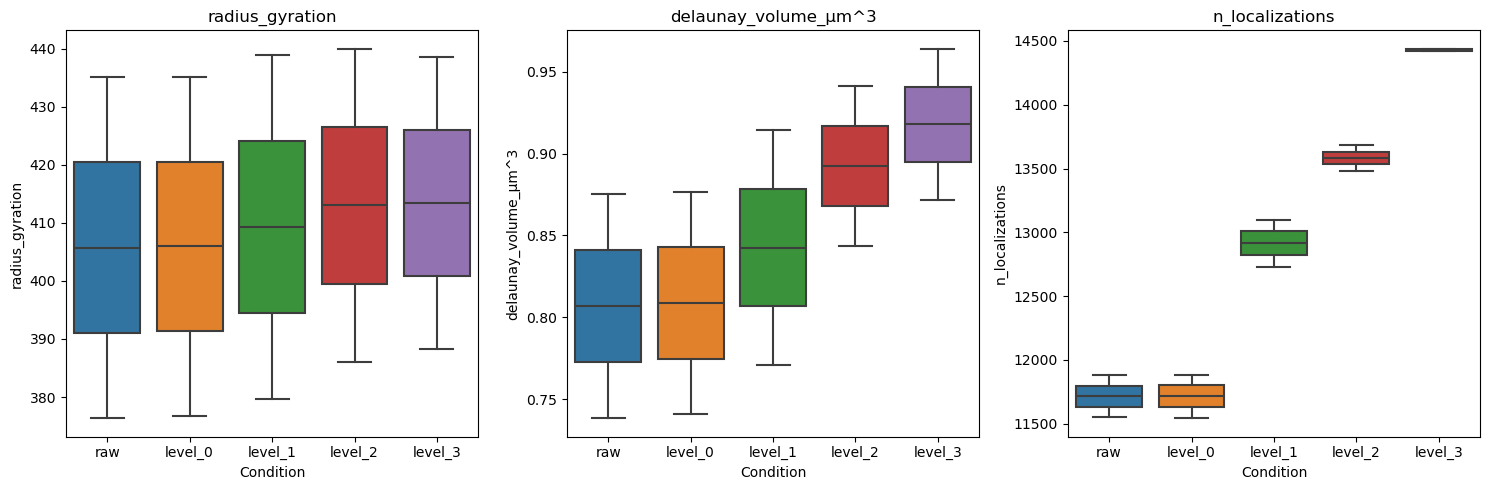

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
metrics = ['radius_gyration', 'delaunay_volume_μm^3', 'n_localizations']


# Create boxplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

for ax, metric in zip(axes, metrics):
    sns.boxplot(data=df, x='condition', y=metric, ax=ax)
    ax.set_title(f'{metric}')
    ax.set_xlabel('Condition')
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

